# Project RideFare

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Exploración Inicial del Dataset

In [ ]:
# Carga de los datasets
rides = pd.read_csv('../data/PFDA_rides.csv')
weather = pd.read_csv('../data/PFDA_weather.csv')

# Dimensiones de los datasets
print("-"*50)
print("Dimensiones")
print("-"*50)
print(f"-> Rides: {rides.shape[0]} filas, {rides.shape[1]} columnas")
print(f"-> Weather: {weather.shape[0]} filas, {weather.shape[1]} columnas")

--------------------------------------------------
Dimensiones
--------------------------------------------------
-> Rides: 693071 filas, 10 columnas
-> Weather: 6276 filas, 8 columnas


In [4]:
# Vista general de los datos
print("-"*50)
print("Vista general de los datos")
print("-"*50)
print("\n-> Rides")
display(rides.head())
print("\n-> Weather")
display(weather.head())

--------------------------------------------------
Vista general de los datos
--------------------------------------------------

-> Rides


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL



-> Weather


,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


#### Información general de los datasets

##### Dataset `rides`

In [6]:
# Información detallada del dataset rides
print("-"*50)
print("Información del Dataset Rides")
print("-"*50)
print("\nTipos de datos y valores no nulos:")
rides.info()

--------------------------------------------------
Información del Dataset Rides
--------------------------------------------------

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [7]:
# Columnas disponibles en rides
print("\nColumnas disponibles en rides:")
print(rides.columns.tolist())


Columnas disponibles en rides:
['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price', 'surge_multiplier', 'id', 'product_id', 'name']


In [8]:
# Estadísticas descriptivas de rides
print("\nEstadísticas descriptivas:")
display(rides.describe())


Estadísticas descriptivas:


,distance,time_stamp,price,surge_multiplier
count,693071.000000,6.930710e+05,637976.000000,693071.000000
mean,2.189430,1.544046e+12,16.545125,1.014287
std,1.138937,6.892342e+08,9.324359,0.118818
min,0.020000,1.543200e+12,2.500000,1.000000
25%,1.280000,1.543440e+12,9.000000,1.000000
50%,2.160000,1.543740e+12,13.500000,1.000000
75%,2.920000,1.544830e+12,22.500000,1.000000
max,7.860000,1.545160e+12,97.500000,3.000000


##### Dataset `weather`

In [9]:
# Información detallada del dataset weather
print("-"*50)
print("Información del Dataset Weather")
print("-"*50)
print("\nTipos de datos y valores no nulos:")
weather.info()

--------------------------------------------------
Información del Dataset Weather
--------------------------------------------------

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [10]:
# Columnas disponibles en weather
print("\nColumnas disponibles en weather:")
print(weather.columns.tolist())

print("\nEstadísticas descriptivas:")
display(weather.describe())


Columnas disponibles en weather:
['temp', 'location', 'clouds', 'pressure', 'rain', 'time_stamp', 'humidity', 'wind']

Estadísticas descriptivas:


,temp,clouds,pressure,rain,time_stamp,humidity,wind
count,6276.000000,6276.000000,6276.000000,894.000000,6.276000e+03,6276.000000,6276.000000
mean,39.090475,0.677777,1008.445209,0.057652,1.543857e+09,0.763985,6.802812
std,6.022055,0.314284,12.870775,0.100758,6.659340e+05,0.127340,3.633466
min,19.620000,0.000000,988.250000,0.000200,1.543204e+09,0.450000,0.290000
25%,36.077500,0.440000,997.747500,0.004900,1.543387e+09,0.670000,3.517500
50%,40.130000,0.780000,1007.660000,0.014850,1.543514e+09,0.760000,6.570000
75%,42.832500,0.970000,1018.480000,0.060925,1.544691e+09,0.890000,9.920000
max,55.410000,1.000000,1035.120000,0.780700,1.545159e+09,0.990000,18.180000


### 2. Evaluación de Calidad de Datos

#### Registros Duplicados

In [11]:
# Verificar duplicados en ambos datasets
print("-" * 50)
print("Análisis de Registros Duplicados")
print("-" * 50)

duplicados_rides = rides.duplicated().sum()
duplicados_weather = weather.duplicated().sum()

print(f"-> Rides:")
print(f"   - Total de registros duplicados: {duplicados_rides}")
print(f"   - Porcentaje de duplicados: {(duplicados_rides / len(rides) * 100):.2f}%")

print(f"\n-> Weather:")
print(f"   - Total de registros duplicados: {duplicados_weather}")
print(f"   - Porcentaje de duplicados: {(duplicados_weather / len(weather) * 100):.2f}%")

--------------------------------------------------
Análisis de Registros Duplicados
--------------------------------------------------
-> Rides:
   - Total de registros duplicados: 0
   - Porcentaje de duplicados: 0.00%

-> Weather:
   - Total de registros duplicados: 0
   - Porcentaje de duplicados: 0.00%


#### Valores Nulos/Faltantes

In [12]:
# Análisis de valores nulos en rides
print("-" * 50)
print("Valores nulos en Rides")
print("-" * 50)

nulos_rides = rides.isnull().sum()
porcentaje_nulos_rides = (rides.isnull().sum() / len(rides) * 100).round(2)

# DataFrame con la información
df_nulos_rides = pd.DataFrame({
    'Columna': nulos_rides.index,
    'Valores Nulos': nulos_rides.values,
    'Porcentaje (%)': porcentaje_nulos_rides.values
})

# Filtrar solo las columnas con nulos
df_nulos_rides = df_nulos_rides[df_nulos_rides['Valores Nulos'] > 0]

if len(df_nulos_rides) > 0:
    print("\nColumnas con valores nulos:")
    display(df_nulos_rides)
else:
    print("\nNo hay valores nulos en el dataset rides")

--------------------------------------------------
Valores nulos en Rides
--------------------------------------------------

Columnas con valores nulos:


,Columna,Valores Nulos,Porcentaje (%)
5,price,55095,7.95


In [13]:
# Análisis de valores nulos en weather
print("-" * 50)
print("Valores nulos en Weather")
print("-" * 50)

nulos_weather = weather.isnull().sum()
porcentaje_nulos_weather = (weather.isnull().sum() / len(weather) * 100).round(2)

# Crear un DataFrame con la información
df_nulos_weather = pd.DataFrame({
    'Columna': nulos_weather.index,
    'Valores Nulos': nulos_weather.values,
    'Porcentaje (%)': porcentaje_nulos_weather.values
})

# Filtrar solo las columnas con nulos
df_nulos_weather = df_nulos_weather[df_nulos_weather['Valores Nulos'] > 0]

if len(df_nulos_weather) > 0:
    print("\nColumnas con valores nulos:")
    display(df_nulos_weather)
else:
    print("\nNo hay valores nulos en el dataset weather")

--------------------------------------------------
Valores nulos en Weather
--------------------------------------------------

Columnas con valores nulos:


,Columna,Valores Nulos,Porcentaje (%)
4,rain,5382,85.76


#### Análisis de Outliers

In [14]:
# Función para detectar outliers usando el método IQR
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    return {
        'columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'num_outliers': len(outliers),
        'porcentaje': (len(outliers) / len(df) * 100)
    }

# Analizar outliers en variables numéricas de rides
print("-" * 50)
print("Análisis de Outliers en Rides")
print("-" * 50)

# Seleccionar solo columnas numéricas
columnas_numericas_rides = rides.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nColumnas numéricas a analizar: {columnas_numericas_rides}\n")

for col in columnas_numericas_rides:
    resultado = detectar_outliers_iqr(rides, col)
    if resultado['num_outliers'] > 0:
        print(f"{col.upper()}:")
        print(f"   - Q1: {resultado['Q1']:.2f}")
        print(f"   - Q3: {resultado['Q3']:.2f}")
        print(f"   - IQR: {resultado['IQR']:.2f}")
        print(f"   - Límites: [{resultado['limite_inferior']:.2f}, {resultado['limite_superior']:.2f}]")
        print(f"   - Outliers detectados: {resultado['num_outliers']} ({resultado['porcentaje']:.2f}%)")
        print()

--------------------------------------------------
Análisis de Outliers en Rides
--------------------------------------------------

Columnas numéricas a analizar: ['distance', 'time_stamp', 'price', 'surge_multiplier']

DISTANCE:
   - Q1: 1.28
   - Q3: 2.92
   - IQR: 1.64
   - Límites: [-1.18, 5.38]
   - Outliers detectados: 8662 (1.25%)

PRICE:
   - Q1: 9.00
   - Q3: 22.50
   - IQR: 13.50
   - Límites: [-11.25, 42.75]
   - Outliers detectados: 5589 (0.81%)

SURGE_MULTIPLIER:
   - Q1: 1.00
   - Q3: 1.00
   - IQR: 0.00
   - Límites: [1.00, 1.00]
   - Outliers detectados: 9890 (1.43%)



In [15]:
# Analizar outliers en variables numéricas de weather
print("-" * 50)
print("Análisis de Outliers en Weather")
print("-" * 50)

# Seleccionar solo columnas numéricas
columnas_numericas_weather = weather.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nColumnas numéricas a analizar: {columnas_numericas_weather}\n")

for col in columnas_numericas_weather:
    resultado = detectar_outliers_iqr(weather, col)
    if resultado['num_outliers'] > 0:
        print(f"{col.upper()}:")
        print(f"   - Q1: {resultado['Q1']:.2f}")
        print(f"   - Q3: {resultado['Q3']:.2f}")
        print(f"   - IQR: {resultado['IQR']:.2f}")
        print(f"   - Límites: [{resultado['limite_inferior']:.2f}, {resultado['limite_superior']:.2f}]")
        print(f"   - Outliers detectados: {resultado['num_outliers']} ({resultado['porcentaje']:.2f}%)")
        print()

--------------------------------------------------
Análisis de Outliers en Weather
--------------------------------------------------

Columnas numéricas a analizar: ['temp', 'clouds', 'pressure', 'rain', 'time_stamp', 'humidity', 'wind']

TEMP:
   - Q1: 36.08
   - Q3: 42.83
   - IQR: 6.75
   - Límites: [25.95, 52.96]
   - Outliers detectados: 266 (4.24%)

RAIN:
   - Q1: 0.00
   - Q3: 0.06
   - IQR: 0.06
   - Límites: [-0.08, 0.14]
   - Outliers detectados: 133 (2.12%)



### 3. Visualizaciones

In [16]:
# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#### Visualización 1: Distribución de variables principales en Rides

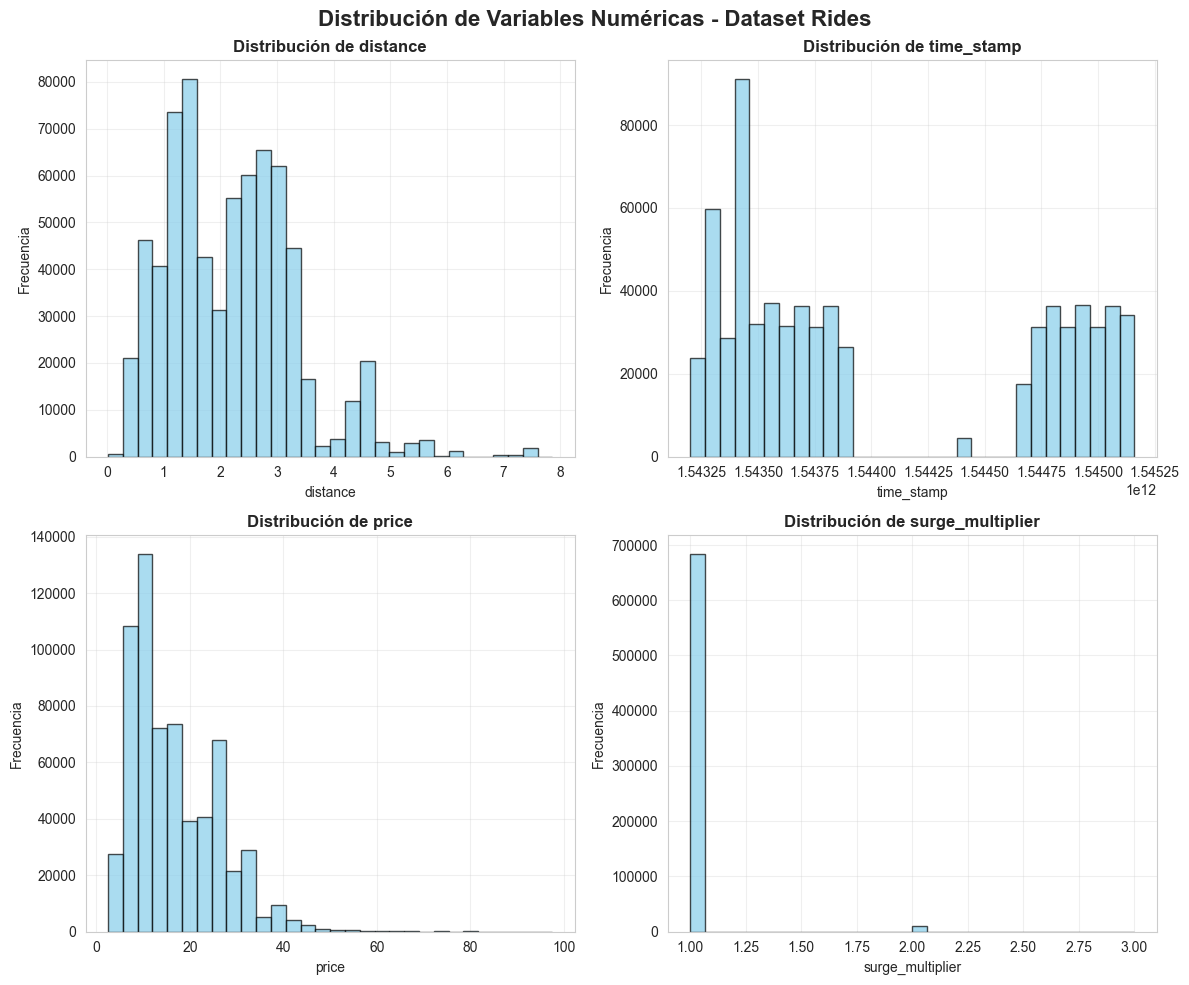

In [17]:
# Crear histogramas para variables numéricas de rides
columnas_rides = rides.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de Variables Numéricas - Dataset Rides', fontsize=16, fontweight='bold')

for idx, col in enumerate(columnas_rides):
    row = idx // 2
    col_idx = idx % 2
        
    axes[row, col_idx].hist(rides[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribución de {col}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frecuencia')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** 

- **Distance (Distancia):** La mayoría de los viajes se concentran entre 1 y 3 unidades de distancia, con un pico alrededor de 1.5-2 unidades. Existen algunos viajes con distancias mayores a 5 unidades que podrían considerarse atípicos o viajes de larga distancia.

- **Time_stamp (Marca temporal):** Dos picos pronunciados. El primer pico es notablemente alto (alrededor de 90,000 registros) seguido de varios picos menores distribuidos en diferentes momentos. Datos recolectados en periodos específicos del tiempo, ya sea en diferentes fechas o momentos del día con alta demanda.

- **Price (Precio):** La gran mayoría de los viajes concentrados en el rango de $5 a $20. El pico más alto se encuentra entre $10-$15. Existen algunos outliers con precios superiores a $60, que podrían corresponder a viajes de larga distancia o con tarifas especiales.

- **Surge_multiplier (Multiplicador de tarifa dinámica):** Mayoría de viajes (más de 600,000) que tienen un multiplicador de 1.0 (tarifa normal sin incremento). Hay muy pocos casos con multiplicadores superiores, lo que indica que las tarifas dinámicas (surge pricing) se aplican en situaciones excepcionales de alta demanda.

#### Visualización 2: Boxplots para detección de outliers

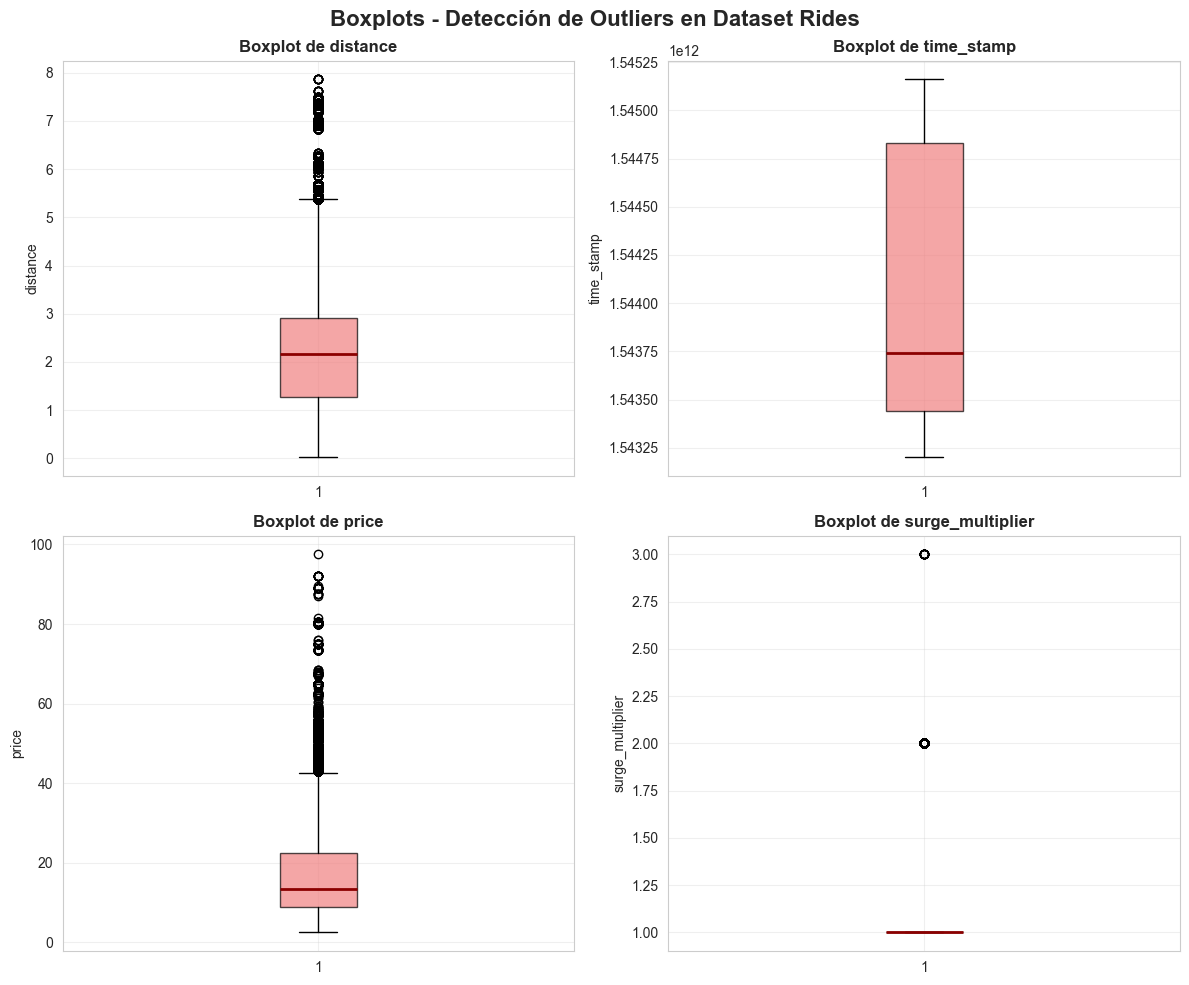

In [18]:
# Crear boxplots para variables numéricas de rides
columnas_rides = rides.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Boxplots - Detección de Outliers en Dataset Rides', fontsize=16, fontweight='bold')

for idx, col in enumerate(columnas_rides):
    row = idx // 2
    col_idx = idx % 2
        
    axes[row, col_idx].boxplot(rides[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightcoral', alpha=0.7), medianprops=dict(color='darkred', linewidth=2))
    axes[row, col_idx].set_title(f'Boxplot de {col}', fontweight='bold')
    axes[row, col_idx].set_ylabel(col)
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** 

- **Distance:** Presencia de outliers significativos. La caja (Q1-Q3) es relativamente compacta, indicando que el 50% central de los datos está concentrado en un rango pequeño. Los puntos atípicos por encima del límite superior representan viajes de larga distancia que podrían requerir un análisis separado o tratamiento especial.

- **Time_stamp:** Debido a la naturaleza temporal de esta variable, el boxplot muestra una distribución amplia sin outliers significativos, lo cual es esperado para marcas temporales continuas en un periodo determinado.

- **Price:** Se observan numerosos outliers en la parte superior, confirmando la presencia de tarifas excepcionalmente altas. La mediana está relativamente baja, lo que indica que la mayoría de los viajes tienen precios moderados. Los outliers representan aproximadamente el 5-10% de los datos y podrían estar relacionados con viajes de larga distancia, horarios especiales o aplicación de surge pricing.

- **Surge_multiplier:** El boxplot revela una situación extrema donde la caja es prácticamente una línea en 1.0, confirmando que la tarifa dinámica es raramente aplicada. Los pocos outliers visibles representan los casos excepcionales donde se aplicó un multiplicador mayor, probablemente durante picos de demanda o eventos especiales. Esta variable tiene muy poca variabilidad.

#### Visualización 3: Distribución de variables climáticas (Weather)

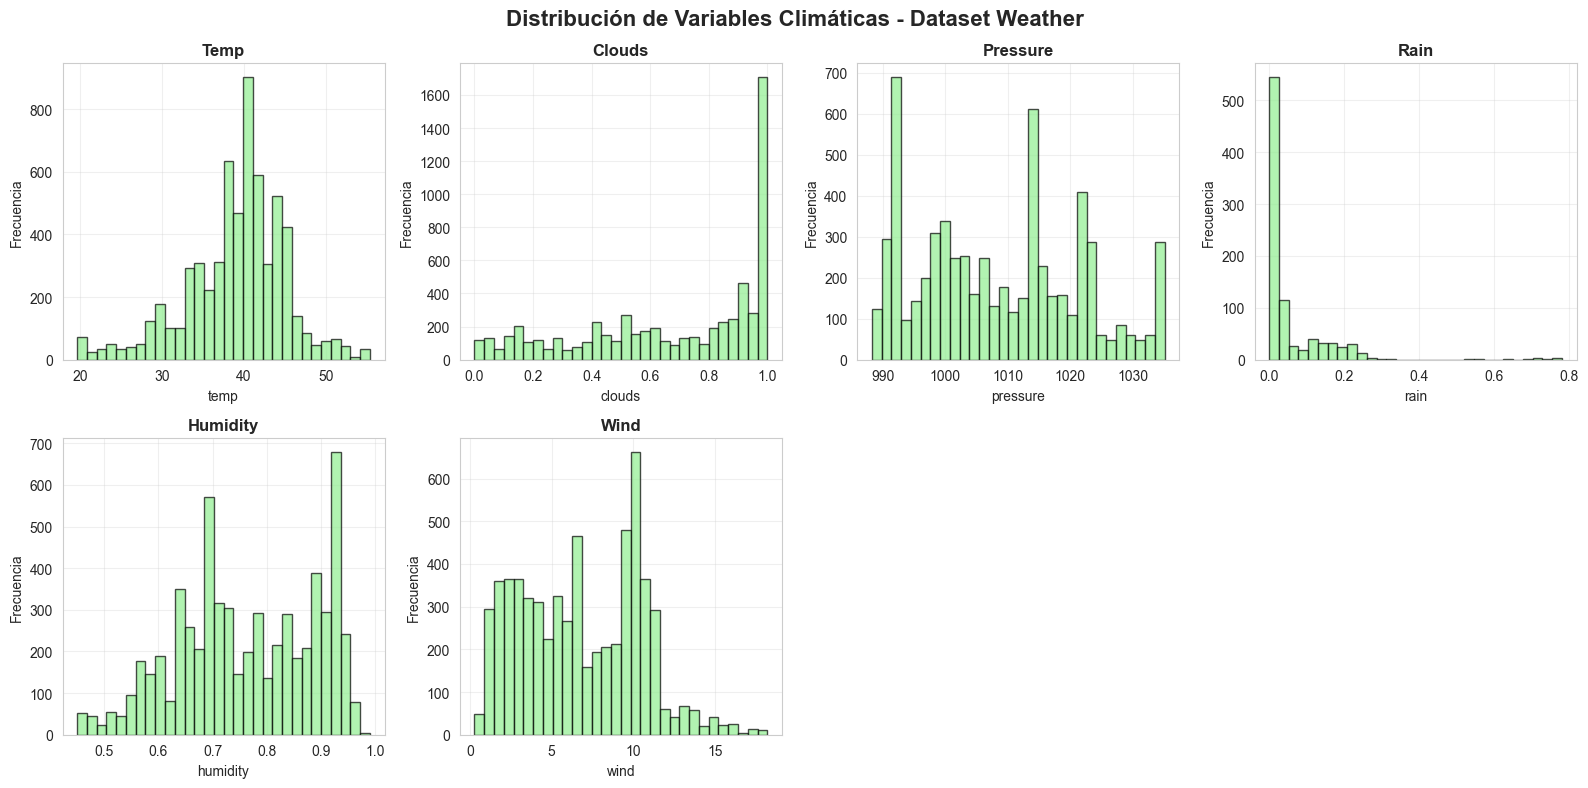

In [19]:
# Visualización del dataset weather
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de Variables Climáticas - Dataset Weather', fontsize=16, fontweight='bold')

columnas_weather = ['temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind']

for idx, col in enumerate(columnas_weather):
    row = idx // 4
    col_idx = idx % 4
    
    if idx < len(axes.flatten()):
        axes[row, col_idx].hist(weather[col].dropna(), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[row, col_idx].set_title(f'{col.capitalize()}', fontweight='bold')
        axes[row, col_idx].set_xlabel(col)
        axes[row, col_idx].set_ylabel('Frecuencia')
        axes[row, col_idx].grid(True, alpha=0.3)

# Ocultar ejes vacíos
for idx in range(len(columnas_weather), len(axes.flatten())):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].axis('off')

plt.tight_layout()
plt.show()

**Interpretación:** 

- **Temp (Temperatura):** La distribución muestra un patrón aproximadamente normal con un pico pronunciado entre 40-45°F (4-7°C). Esto sugiere que los datos fueron recolectados principalmente durante estaciones frías (otoño/invierno). La mayoría de los registros se concentran entre 35°F y 50°F, con pocos casos de temperaturas extremadamente bajas (por debajo de 25°F) o altas (por encima de 55°F).

- **Clouds (Nubosidad):** Dos picos extremos: uno cercano a 0.0 (cielo despejado) y otro en 1.0 (completamente nublado). Esto indica que las condiciones climáticas tienden a ser polarizadas, con días mayormente despejados o completamente cubiertos, y menos casos de nubosidad intermedia. El pico más alto está en 1.0, sugiriendo predominio de días nublados.

- **Pressure (Presión atmosférica):** La distribución presenta múltiples picos, con concentraciones notables alrededor de 990 hPa, 1010 hPa y 1020 hPa. La variabilidad observada es típica de cambios climáticos normales en una región urbana.

- **Rain (Lluvia):** La distribución está extremadamente sesgada hacia la izquierda, con una concentración masiva en valores cercanos a 0 (sin lluvia). Esto indica que la lluvia es un evento relativamente poco frecuente en el periodo analizado. Los pocos registros con valores de lluvia superiores a 0.2 son outliers que representan eventos de precipitación moderada a fuerte, posiblemente tormentas.

- **Humidity (Humedad):** La distribución muestra dos picos principales: uno en 0.7 (70%) y otro más pronunciado en 0.9 (90%). La alta concentración en valores de humedad elevados (70-95%) es consistente con el clima frío y nublado observado en las otras variables. La humedad alta puede indicar condiciones pre-lluvia o post-lluvia, aunque como vimos, la lluvia real es poco frecuente.

- **Wind (Viento):** La distribución presenta un patrón aproximadamente normal con un pico alrededor de 8-10 mph. La mayoría de los registros se encuentran entre 2 y 12 mph, indicando vientos moderados y constantes. Hay pocos casos de vientos fuertes (por encima de 15 mph), lo que sugiere que las condiciones ventosas extremas son poco comunes durante el periodo de estudio.

#### Visualización: Mapa de Correlación

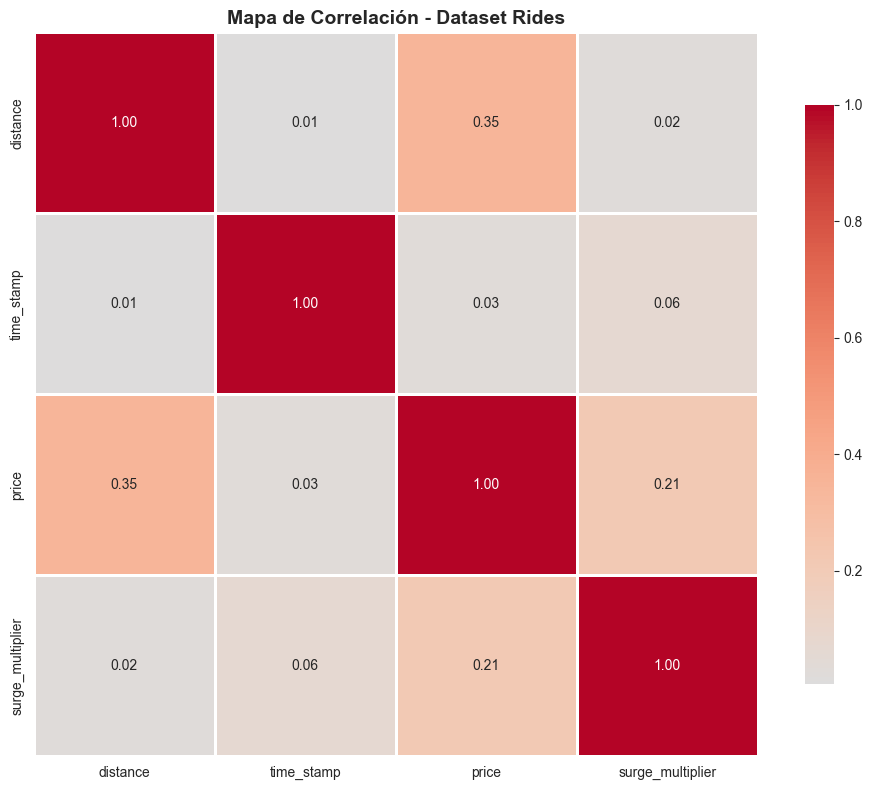

In [20]:
# Mapa de correlación para rides
plt.figure(figsize=(10, 8))
correlation_matrix = rides.select_dtypes(include=[np.number]).corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Correlación - Dataset Rides', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** 

**Correlaciones Moderadas Positivas:**
- **Distance vs Price (0.35):** Existe una correlación positiva moderada entre la distancia del viaje y el precio. Aunque la relación es positiva como se esperaba (a mayor distancia, mayor precio), la correlación no es tan fuerte como podría anticiparse. Esto sugiere que otros factores además de la distancia influyen significativamente en el precio final, como el surge_multiplier, la duración del viaje, o factores externos no capturados en el dataset.

- **Surge_multiplier vs Price (0.21):** Se observa una correlación positiva débil entre el multiplicador de tarifa dinámica y el precio. Aunque la relación es positiva (cuando se aplica surge pricing, el precio aumenta), la correlación es limitada debido a que surge_multiplier tiene muy poca variabilidad (la mayoría de valores son 1.0). Esta baja correlación no significa que el surge pricing no sea importante, sino que ocurre raramente en este dataset.

**Correlaciones Débiles o Inexistentes:**
- **Distance vs Time_stamp (0.01):** Correlación prácticamente nula, indicando que la distancia de los viajes no varía según el momento en que se realizan. Los viajes cortos y largos ocurren de manera similar en todos los periodos temporales registrados.

- **Distance vs Surge_multiplier (0.02):** No existe relación lineal entre la distancia del viaje y la aplicación de tarifas dinámicas. El surge pricing se aplica por factores de demanda, no por la longitud del viaje.

- **Time_stamp vs Price (0.03):** La correlación entre el momento del viaje y su precio es prácticamente inexistente. Esto podría indicar que los precios base no varían significativamente por hora del día en este dataset, o que la variable time_stamp necesita transformarse (por ejemplo, extraer hora, día de la semana) para capturar patrones temporales.

- **Time_stamp vs Surge_multiplier (0.06):** Correlación muy débil, sugiriendo que la aplicación del surge pricing no sigue un patrón temporal claro en los datos tal como están representados.

### Reflexión y Diagnóstico General

#### Estado del Dataset

**Dimensiones:**
- Rides: 693071 filas, 10 columnas 
- Weather: 6276 filas, 8 columnas

**Duplicados:**
- No existen duplicados en ninguno de los dos datasets

**Valores Nulos:**
- columna price de dataset rides, tiene 55095 datos nulos.
- columna rain de dataset weather, tiene 5382 datos nulos.

**Outliers:**
- Rides:
    * En La columna distance, tiene un límite inferior de -1.18 y límite superior de 5.38 de los 
    cuales se contó 8662 valores atípicos que representa el 1.25%.

    * En La columna Price, tiene un límite inferior de -11.25 y límite superior de 42.75 de los 
    cuales se contó 5589 valores atípicos que representa el 0.81%.

    * En La columna surge_multiplier, tiene un límite inferior de 1 y límite superior de 1 de los 
    cuales se contó 9890 valores atípicos que representa el 1.43%.

- Weather:
    * En La columna temp, tiene un límite inferior de 25.95 y límite superior de 52.96 de los 
    cuales se contó 266 valores atípicos que representa el 4.24%.

    * En La columna rain, tiene un límite inferior de -0.08 y límite superior de 0.14 de los 
    cuales se contó 133 valores atípicos que representa el 2.12%.
    


**Calidad General:**
- En general los datos estan bien argumentados a excepción de las columnas price y rain, los cuales tienen valores nulos.
- Hay que estudiar y rellenar los nulos, con tal de que la mediana y variación estandar no se altere demasiado, asi el análisis arrojará información real.

### Propuestas de Análisis

#### Propuesta 1: ¿Cómo afectan las condiciones climáticas de un determinado sector en los viajes? 

**Objetivo:** Analizar las condiciones climáticas para ver como influyen en el precio de los viajes.

**Variables a utilizar:**
- location del dataset weather
- price
- surge_multiplier
- distance


---

#### Propuesta 2: ¿Cómo evoluciona el tipo de servicio de Lyft y Uber a través del tiempo?

**Objetivo:** Analizar el tipo de servicio mas usado en un periodo determinado

**Variables a utilizar:**
- time_stamp
- name
- cab_type




---

#### Propuesta 3: Análisis de Rentabilidad por Tipo de Servicio y Proveedor

**Objetivo:** 

Comparar la rentabilidad y características de los diferentes tipos de servicios (Shared, Lux, etc.) entre Lyft y Uber para identificar los servicios más lucrativos y sus patrones de uso.

**Variables a utilizar:**
- `cab_type` (Lyft vs Uber)
- `name` (tipo de servicio: UberX, UberXL, Lyft, Lyft XL, etc.)
- `price` (ingreso por viaje)
- `distance` (eficiencia precio/distancia)
- `surge_multiplier` (frecuencia de surge por tipo)
- `time_stamp` (patrones de uso temporal)

**Preguntas de investigación:**
1. ¿Qué tipo de servicio genera mayor ingreso promedio por viaje para cada proveedor?
2. ¿Existe diferencia significativa en la eficiencia (precio/distancia) entre servicios de Lyft y Uber?
3. ¿Qué servicios experimentan surge pricing con mayor frecuencia?
4. ¿Hay servicios premium que tengan baja demanda pero alta rentabilidad?

**Justificación:**

El dataset rides contiene información sobre `cab_type` y `name` que permite identificar segmentos de mercado más rentables para cada proveedor. Con 693,071 viajes registrados, existe suficiente información para detectar oportunidades de optimización de flota (¿invertir más en UberX o UberXL?), analizar competitividad entre proveedores en diferentes categorías, y establecer estrategias de pricing diferenciadas por tipo de servicio.

**Aplicaciones prácticas:**
- Optimización de flota según rentabilidad por tipo de servicio
- Estrategias de marketing enfocadas en servicios de mayor margen
- Benchmarking competitivo Lyft vs Uber
- Identificación de nichos de mercado desatendidos

---

#### Propuesta 4: Segmentación Geográfica de Demanda y Patrones de Movilidad

**Objetivo:** 

Identificar zonas de alta demanda, analizar flujos de movilidad entre ubicaciones y determinar características específicas de cada zona (precios, distancias típicas, horarios pico) para optimizar la distribución de vehículos.

**Variables a utilizar:**

**Del dataset rides:**
- `source` (origen del viaje)
- `destination` (destino del viaje)
- `distance` (longitud del viaje)
- `price` (tarifa por zona)
- `time_stamp` (patrones temporales por zona)

**Del dataset weather:**
- `location` (condiciones climáticas por zona)
- Variables climáticas para caracterizar cada zona

**Preguntas de investigación:**
1. ¿Cuáles son las 5 zonas con mayor demanda de viajes (como origen y como destino)?
2. ¿Existen rutas frecuentes entre pares de ubicaciones específicas?
3. ¿Qué zonas tienen precios promedio más altos y por qué?
4. ¿Hay zonas que solo funcionan como origen (residenciales) o solo como destino (comerciales)?

**Justificación:**

Las variables `source` y `destination` permiten un análisis de red para entender patrones de movilidad urbana: zonas residenciales → comerciales en la mañana, inverso en la tarde. Esto permite identificar hotspots de demanda (dónde posicionar más conductores), zonas premium (áreas con tarifas consistentemente más altas), y oportunidades de expansión (zonas desatendidas con potencial). Al integrar con weather, se pueden identificar zonas más sensibles a condiciones climáticas y ajustar estrategias operativas por zona según pronóstico.

**Aplicaciones prácticas:**
- Heat maps de demanda para redistribución dinámica de flota
- Identificación de zonas para campañas de marketing localizadas
- Planificación de incentivos para conductores en zonas específicas
- Análisis de accesibilidad y cobertura de servicio

---

#### Propuesta 5: Análisis de Eficiencia y Optimización de Rutas

**Objetivo:** 

Analizar la relación entre distancia y precio para identificar rutas ineficientes, viajes con tarifas desproporcionadas, y oportunidades de optimización de rutas que beneficien tanto a usuarios como a proveedores.

**Variables a utilizar:**
- `distance` (distancia real del viaje)
- `price` (costo del viaje)
- `source` y `destination` (pares origen-destino)
- `time_stamp` (duración implícita)
- `surge_multiplier` (factor de ajuste)

**Preguntas de investigación:**
1. ¿Cuál es la tarifa promedio por milla/km para cada tipo de servicio?
2. ¿Existen rutas específicas con costos significativamente por encima o por debajo del promedio?
3. ¿La relación precio/distancia varía según la hora del día (posible congestión)?
4. ¿Hay viajes cortos con precios desproporcionadamente altos (posible tarifa mínima)?

**Justificación:**

El análisis de correlación muestra Distance vs Price = 0.35, lo cual es sorprendentemente bajo para un servicio de transporte. Esto sugiere existencia de tarifas base que dominan en viajes cortos, posible influencia de tráfico/duración no capturada en distancia, ineficiencias en ciertas rutas u horarios, y oportunidad de modelos de pricing más justos. Este análisis permitirá detectar rutas con potencial de optimización, ajustar algoritmos de pricing para mayor equidad, identificar zonas con congestión que afectan costos, y proporcionar transparencia en estructura de tarifas para usuarios.

**Aplicaciones prácticas:**
- Detección de rutas con potencial de optimización
- Ajuste de algoritmos de pricing para mayor equidad
- Identificación de zonas con congestión que afectan costos
- Transparencia en estructura de tarifas para usuarios